# 完成目标

1. 解释 LLM、token、context window 等核心概念。  
2. 使用 Python 调用 Claude / GPT / Gemini API。
3. 比较不同 LLM 提供商（Claude / GPT / Gemini / Llama）的优劣。
4. 理解 per-token 定价模型并估算成本。

## 核心词

token   输入LLM就是一个个词元，基本单位  

context window    模型一次最多看到多少token

temperature  LLM本质上是预测，概率分布选词，temperature控制回答发散还是稳定

## 网络基础知识

1. 什么是restful api  

REpresentational State Transfer 表现层状态转移  
是一种建议的代码风格不是规范
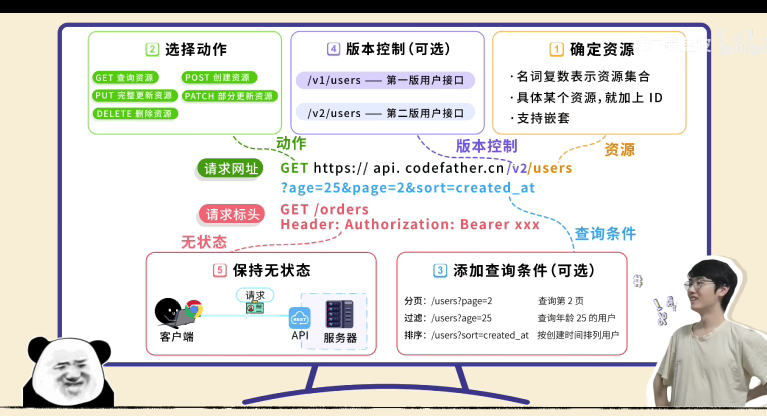

2. 实际项目写法（全部 POST，动词塞 body 里）  
POST /api/rpc  
{"method": "getUser",    "params": {"id": 42}}  
{"method": "updateUser", "params": {"id": 42, "name": "Bob"}}  
{"method": "deleteUser", "params": {"id": 42}}   

## 手搓一个API

### 调用deepseek api

In [ ]:
## 掌握能力
# web api 指的是 专通过HTTP协议、走网络的api
# 客户端发http请求，服务端返回json，网络传输。
# 一个web api 通常有多个endpoint
## POST   /v1/chat/completions     ← 一个 endpoint（聊天补全）
## POST   /v1/embeddings           ← 另一个 endpoint（向量化）
## GET    /v1/models               ← 又一个 endpoint（列出模型）
## POST   /v1/images/generations   ← 再一个 endpoint（生成图片）



# 调用 deepseek api
import requests
import os

resp = requests.post(
    "https://api.deepseek.com/v1/chat/completions",
    headers={
        "Authorization": f"Bearer sk-44f729b1ca1140**********4a21d1c3f0",
        "Content-Type": "application/json",
    },
    json={  # 用 json= 参数，requests 自动处理编码
        "model": "deepseek-v4-pro",
        "messages": [
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": "Hello!介绍一下你自己"},
        ],
        "thinking": {"type": "enabled"},
        "reasoning_effort": "high",
        "stream": False,
    },
)

print(resp.json()["choices"][0]["message"]["content"])

#resp.json()
# └── "choices"          ← 列表（为什么是列表？因为可以一次返回多个候选回复）
#      └── [0]           ← 第一个回复（n=1 时永远只有一个）
#           └── "message" ← 消息对象
#                ├── "role"              → "assistant"
#                ├── "content"           → "Hello! I'm an AI..."   ← 你要的
#                └── "reasoning_content" → "We are asked: ..."     ← 思考过程

你好呀！很高兴认识你！😊

我是**DeepSeek**，由深度求索公司创造的AI助手。我是最新版本的模型，专门为你提供各种帮助！

**关于我的一些小特点：**
- 📚 **超长上下文**：可以一次性处理1M token的内容，相当于三体三部曲那么大的体量！
- 📎 **文件处理能力**：虽然我不支持多模态识别图片，但可以上传图片、PDF、Word、Excel等文件，我会读取其中的文字信息来帮你
- 🔗 **联网搜索**：需要时可以联网查找最新信息（需要你在Web/App上手动开启哦）
- 🎤 **App端语音输入**：在移动端可以说话输入，更方便
- 💰 **完全免费**：目前没有任何收费计划，放心使用！

**我能帮你做什么？**
回答问题、写文章、编程、翻译、分析文档、头脑风暴……几乎任何文字相关的任务都可以交给我！

有什么我可以帮你的吗？尽管问，我会尽全力帮你解决～✨


### 手搓 api
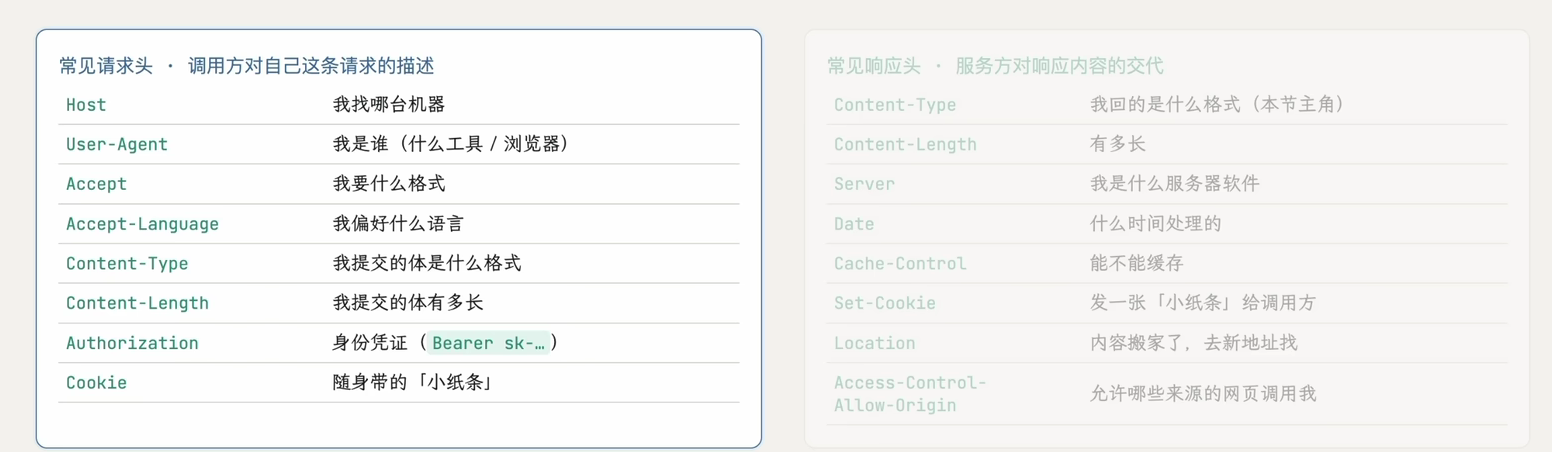

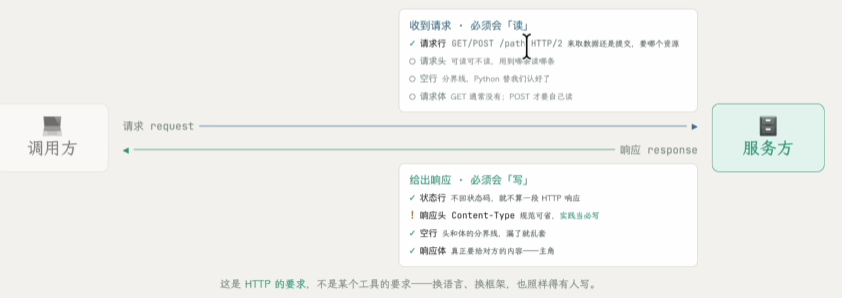

必备：  
1. 请求行  GET/POST 
2. 状态行、空行、响应体。 Content-type 响应头必须写！
3. http.server 

详见文件夹 CreateApi

## Claude模型概述

## OLLama

用来验证代码逻辑；跑 prompt engineering 实验，跑tool-use/ReAct 循环，做function calling 练习。
gemma4:e4b 跑通 Path A 的练习